In [1]:
from pathlib import Path
from getpass import getpass
import warnings
import os
import sys
import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

from sqlalchemy import create_engine, inspect, text
from sqlalchemy.engine import URL

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)


In [2]:
PROJECT_ROOT = Path(r"C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
PREDICTIONS_DIR = DATA_DIR / "predictions"
MODEL_DIR = PROJECT_ROOT / "models"

PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DATABASE_NAME = "ecommerce_ai_db"
DB_HOST = "localhost"
DB_PORT = 5432

FORECAST_HORIZON = 30

print(PROJECT_ROOT)
print(PREDICTIONS_DIR)
print(MODEL_DIR)


C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\predictions
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\models


In [3]:
db_user = input("PostgreSQL Username: ").strip()
db_password = getpass("PostgreSQL Password: ")

connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username=db_user,
    password=db_password,
    host=DB_HOST,
    port=DB_PORT,
    database=DATABASE_NAME,
)

engine = create_engine(
    connection_url,
    future=True,
    pool_pre_ping=True
)

raw_connection = psycopg2.connect(
    dbname=DATABASE_NAME,
    user=db_user,
    password=db_password,
    host=DB_HOST,
    port=DB_PORT
)

print("PostgreSQL connection created successfully.")

PostgreSQL Username:  postgres
PostgreSQL Password:  ········


PostgreSQL connection created successfully.


In [4]:
try:
    with engine.connect() as conn:
        version = conn.execute(
            text("SELECT version();")
        ).scalar()

    print(version)

except Exception as e:
    raise RuntimeError(
        f"Unable to connect to PostgreSQL.\n{e}"
    )

PostgreSQL 18.4 on x86_64-windows, compiled by msvc-19.44.35227, 64-bit


In [5]:
schemas = pd.read_sql(
    """
    SELECT schema_name
    FROM information_schema.schemata
    ORDER BY schema_name;
    """,
    engine,
)

display(schemas)

print(f"Total Schemas Found: {len(schemas)}")

,schema_name
0,analytics
1,feature_engineered
2,forecasting
3,information_schema
4,pg_catalog
5,pg_toast
6,public
7,recommendations
8,sales_analytics


Total Schemas Found: 9


In [6]:
inspector = inspect(engine)

table_records = []

for schema in inspector.get_schema_names():
    if schema.startswith("pg_"):
        continue

    for table in inspector.get_table_names(schema=schema):
        table_records.append(
            {
                "schema": schema,
                "table": table
            }
        )

tables_df = (
    pd.DataFrame(table_records)
    .sort_values(["schema", "table"])
    .reset_index(drop=True)
)

if tables_df.empty:
    raise RuntimeError("No user tables were found in the database.")

display(tables_df)

print(f"Total Tables Found: {len(tables_df)}")

,schema,table
0,analytics,clv_overall_summary
1,analytics,clv_segment_summary
2,analytics,clv_validation
3,analytics,customer_churn_model_metrics
4,analytics,customer_churn_predictions
5,analytics,customer_lifetime_value
6,analytics,customer_segmentation
7,analytics,customer_segmentation_model_evaluation
8,analytics,segment_distribution
9,analytics,segment_feature_means


Total Tables Found: 43


In [7]:
column_records = []

for _, row in tables_df.iterrows():

    schema = row["schema"]
    table = row["table"]

    for column in inspector.get_columns(
        table,
        schema=schema
    ):

        column_records.append(
            {
                "schema": schema,
                "table": table,
                "column": column["name"],
                "data_type": str(column["type"]),
                "nullable": column["nullable"]
            }
        )

columns_df = (
    pd.DataFrame(column_records)
    .sort_values(
        ["schema", "table", "column"]
    )
    .reset_index(drop=True)
)

display(columns_df.head(100))

print(f"Total Columns Found: {len(columns_df)}")

,schema,table,column,data_type,nullable
0,analytics,clv_overall_summary,metric,TEXT,True
1,analytics,clv_overall_summary,value,TEXT,True
2,analytics,clv_segment_summary,average_historical_clv,DOUBLE PRECISION,True
3,analytics,clv_segment_summary,clv_segment,TEXT,True
4,analytics,clv_segment_summary,clv_value_share,DOUBLE PRECISION,True
...,...,...,...,...,...
95,analytics,segment_summary,mean_average_order_value,DOUBLE PRECISION,True
96,analytics,segment_summary,mean_average_review_score,DOUBLE PRECISION,True
97,analytics,segment_summary,mean_cancelled_orders,DOUBLE PRECISION,True
98,analytics,segment_summary,mean_customer_zip_code_prefix,DOUBLE PRECISION,True


Total Columns Found: 399


In [8]:
row_counts = []

with engine.connect() as conn:

    for _, row in tables_df.iterrows():

        schema = row["schema"]
        table = row["table"]

        query = text(
            f'SELECT COUNT(*) FROM "{schema}"."{table}"'
        )

        try:
            count = conn.execute(query).scalar()
        except Exception:
            count = None
            raw_connection.rollback()

        row_counts.append(
            {
                "schema": schema,
                "table": table,
                "rows": count
            }
        )

row_count_df = (
    pd.DataFrame(row_counts)
    .sort_values(
        "rows",
        ascending=False,
        na_position="last"
    )
)

display(row_count_df)

,schema,table,rows
36,recommendations,product_recommendations,986670
35,recommendations,powerbi_product_recommendations,986670
28,public,geolocation,738332
29,public,order_items,112650
30,public,order_payments,103886
14,feature_engineered,order_features,99441
32,public,orders,99441
26,public,customer_churn_predictions,99441
12,feature_engineered,customer_features,99441
27,public,customers,99441


In [9]:
date_keywords = [
    "date",
    "time",
    "timestamp",
    "purchase",
    "created",
    "approved",
    "delivered",
    "shipping",
    "estimated",
    "invoice"
]

candidate_date_columns = (
    columns_df[
        columns_df["column"]
        .str.lower()
        .apply(
            lambda x: any(
                keyword in x
                for keyword in date_keywords
            )
        )
    ]
    .reset_index(drop=True)
)

display(candidate_date_columns)

print(
    f"Candidate Date Columns: {len(candidate_date_columns)}"
)

,schema,table,column,data_type,nullable
0,analytics,customer_churn_predictions,prediction_cutoff_date,TIMESTAMP,True
1,analytics,customer_lifetime_value,customer_lifetime_duration,DOUBLE PRECISION,True
2,analytics,customer_lifetime_value,estimated_future_clv,DOUBLE PRECISION,True
3,analytics,customer_segmentation,customer_lifetime_days,DOUBLE PRECISION,True
4,analytics,customer_segmentation,purchase_frequency,DOUBLE PRECISION,True
5,analytics,customer_segmentation,total_items_purchased,DOUBLE PRECISION,True
6,analytics,segment_feature_means,total_items_purchased,DOUBLE PRECISION,True
7,analytics,segment_summary,max_total_items_purchased,DOUBLE PRECISION,True
8,analytics,segment_summary,mean_total_items_purchased,DOUBLE PRECISION,True
9,analytics,segment_summary,median_total_items_purchased,DOUBLE PRECISION,True


Candidate Date Columns: 45


In [10]:
revenue_keywords = [
    "price",
    "payment",
    "value",
    "amount",
    "revenue",
    "sales",
    "total",
    "cost",
    "freight",
    "subtotal"
]

transaction_keywords = [
    "order",
    "transaction",
    "invoice",
    "purchase",
    "sale"
]

candidate_revenue_columns = (
    columns_df[
        columns_df["column"]
        .str.lower()
        .apply(
            lambda x: any(
                keyword in x
                for keyword in revenue_keywords
            )
        )
    ]
    .reset_index(drop=True)
)

candidate_transaction_columns = (
    columns_df[
        columns_df["column"]
        .str.lower()
        .apply(
            lambda x: any(
                keyword in x
                for keyword in transaction_keywords
            )
        )
    ]
    .reset_index(drop=True)
)

print("Candidate Revenue Columns")
display(candidate_revenue_columns)

print("Candidate Transaction Columns")
display(candidate_transaction_columns)

if candidate_date_columns.empty:
    raise RuntimeError(
        "No candidate date column was discovered."
    )

if candidate_transaction_columns.empty:
    raise RuntimeError(
        "No candidate transaction identifier was discovered."
    )

if candidate_revenue_columns.empty:
    print(
        "No direct revenue column was detected. The notebook will attempt validated revenue construction in the next stage."
    )

Candidate Revenue Columns


,schema,table,column,data_type,nullable
0,analytics,clv_overall_summary,value,TEXT,True
1,analytics,clv_segment_summary,clv_value_share,DOUBLE PRECISION,True
2,analytics,clv_segment_summary,total_historical_clv,DOUBLE PRECISION,True
3,analytics,clv_validation,validation_value,TEXT,True
4,analytics,customer_lifetime_value,historical_customer_value,DOUBLE PRECISION,True
...,...,...,...,...,...
71,sales_analytics,overall_sales_kpis,total_freight_value,NUMERIC,True
72,sales_analytics,overall_sales_kpis,total_items,NUMERIC,True
73,sales_analytics,overall_sales_kpis,total_order_value,NUMERIC,True
74,sales_analytics,overall_sales_kpis,total_orders,BIGINT,True


Candidate Transaction Columns


,schema,table,column,data_type,nullable
0,analytics,customer_segmentation,average_order_value,DOUBLE PRECISION,True
1,analytics,customer_segmentation,cancelled_orders,DOUBLE PRECISION,True
2,analytics,customer_segmentation,late_orders,DOUBLE PRECISION,True
3,analytics,customer_segmentation,purchase_frequency,DOUBLE PRECISION,True
4,analytics,customer_segmentation,total_items_purchased,DOUBLE PRECISION,True
...,...,...,...,...,...
91,sales_analytics,overall_sales_kpis,average_order_value,NUMERIC,True
92,sales_analytics,overall_sales_kpis,cancelled_orders,BIGINT,True
93,sales_analytics,overall_sales_kpis,delivered_orders,BIGINT,True
94,sales_analytics,overall_sales_kpis,total_order_value,NUMERIC,True


In [11]:
candidate_tables = (
    candidate_date_columns[["schema", "table"]]
    .merge(
        candidate_transaction_columns[["schema", "table"]],
        on=["schema", "table"]
    )
    .drop_duplicates()
)

candidate_tables = (
    candidate_tables.merge(
        row_count_df,
        on=["schema", "table"],
        how="left"
    )
    .sort_values(
        "rows",
        ascending=False,
        na_position="last"
    )
    .reset_index(drop=True)
)

display(candidate_tables)

if candidate_tables.empty:
    raise RuntimeError(
        "No table contains both a candidate date column and a candidate transaction identifier."
    )

,schema,table,rows
0,public,order_items,112650
1,analytics,customer_segmentation,99441
2,feature_engineered,customer_features,99441
3,feature_engineered,order_features,99441
4,public,customer_churn_predictions,99441
5,public,orders,99441
6,public,order_reviews,99224
7,feature_engineered,monthly_sales_features,25
8,analytics,segment_feature_means,2
9,analytics,segment_summary,2


In [12]:
table_validation = []

for _, table_row in candidate_tables.iterrows():

    schema = table_row["schema"]
    table = table_row["table"]

    cols = columns_df[
        (columns_df["schema"] == schema)
        &
        (columns_df["table"] == table)
    ]["column"].tolist()

    date_cols = [
        c
        for c in cols
        if any(
            k in c.lower()
            for k in date_keywords
        )
    ]

    revenue_cols = [
        c
        for c in cols
        if any(
            k in c.lower()
            for k in revenue_keywords
        )
    ]

    transaction_cols = [
        c
        for c in cols
        if any(
            k in c.lower()
            for k in transaction_keywords
        )
    ]

    table_validation.append(
        {
            "schema": schema,
            "table": table,
            "date_columns": date_cols,
            "revenue_columns": revenue_cols,
            "transaction_columns": transaction_cols
        }
    )

validation_df = pd.DataFrame(table_validation)

display(validation_df)

,schema,table,date_columns,revenue_columns,transaction_columns
0,public,order_items,[shipping_limit_date],"[freight_value, price]","[order_id, order_item_id]"
1,analytics,customer_segmentation,"[customer_lifetime_days, purchase_frequency, t...","[average_order_value, total_items_purchased, t...","[average_order_value, cancelled_orders, late_o..."
2,feature_engineered,customer_features,"[customer_lifetime_days, first_purchase_date, ...","[average_order_value, total_items_purchased, t...","[average_order_value, cancelled_orders, first_..."
3,feature_engineered,order_features,"[estimated_delivery_days, is_delivered, is_on_...","[max_payment_installments, payment_methods_use...","[order_approved_at, order_delivered_carrier_da..."
4,public,customer_churn_predictions,"[first_order_date, last_order_date, lifetime_d...",[],"[first_order_date, last_order_date, order_count]"
5,public,orders,"[estimated_delivery_days, order_approved_at, o...",[],"[order_approved_at, order_delivered_carrier_da..."
6,public,order_reviews,"[review_answer_timestamp, review_creation_date]",[],[order_id]
7,feature_engineered,monthly_sales_features,[purchase_month_start],"[average_order_value, revenue_growth, total_it...","[average_order_value, cancelled_orders, late_o..."
8,analytics,segment_feature_means,[total_items_purchased],"[average_order_value, total_items_purchased, t...","[average_order_value, cancelled_orders, late_o..."
9,analytics,segment_summary,"[max_total_items_purchased, mean_total_items_p...","[max_average_order_value, max_total_items_purc...","[max_average_order_value, max_cancelled_orders..."


In [13]:
selected_schema = None
selected_table = None
selected_date_column = None
selected_transaction_column = None
selected_revenue_column = None

for _, row in validation_df.iterrows():

    if len(row["date_columns"]) == 0:
        continue

    if len(row["transaction_columns"]) == 0:
        continue

    selected_schema = row["schema"]
    selected_table = row["table"]
    selected_date_column = row["date_columns"][0]
    selected_transaction_column = row["transaction_columns"][0]

    if len(row["revenue_columns"]) > 0:
        selected_revenue_column = row["revenue_columns"][0]

    break

if selected_table is None:
    raise RuntimeError(
        "Unable to determine a valid sales table."
    )

print(selected_schema)
print(selected_table)
print(selected_date_column)
print(selected_transaction_column)
print(selected_revenue_column)

public
order_items
shipping_limit_date
order_id
freight_value


In [14]:
sample_query = f'''
SELECT *
FROM "{selected_schema}"."{selected_table}"
LIMIT 1000
'''

sample_df = pd.read_sql(
    sample_query,
    engine
)

print(sample_df.shape)

display(sample_df.head())

(1000, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [15]:
sample_df[selected_date_column] = pd.to_datetime(
    sample_df[selected_date_column],
    errors="coerce"
)

date_summary = pd.DataFrame(
    {
        "Minimum Date":[sample_df[selected_date_column].min()],
        "Maximum Date":[sample_df[selected_date_column].max()],
        "Null Dates":[sample_df[selected_date_column].isna().sum()],
        "Unique Dates":[sample_df[selected_date_column].nunique()]
    }
)

display(date_summary)

if sample_df[selected_date_column].notna().sum() == 0:
    raise RuntimeError(
        "The discovered date column cannot be parsed as datetime."
    )

,Minimum Date,Maximum Date,Null Dates,Unique Dates
0,2016-10-12 04:44:23,2018-09-03 03:50:23,0,877


In [16]:
if selected_revenue_column is not None:

    revenue_dtype = columns_df[
        (columns_df["schema"] == selected_schema)
        &
        (columns_df["table"] == selected_table)
        &
        (columns_df["column"] == selected_revenue_column)
    ]["data_type"].iloc[0]

    print(revenue_dtype)

else:

    revenue_candidates = columns_df[
        (columns_df["schema"] == selected_schema)
        &
        (columns_df["table"] == selected_table)
    ]

    display(revenue_candidates)

    print(
        "No validated revenue column found."
    )

DOUBLE PRECISION


In [17]:
frequency = "D"

number_of_days = (
    sample_df[selected_date_column].max()
    -
    sample_df[selected_date_column].min()
).days

observations = sample_df[selected_date_column].nunique()

average_gap = number_of_days / max(observations,1)

if average_gap > 20:
    frequency = "M"

elif average_gap > 5:
    frequency = "W"

print(f"Selected Frequency : {frequency}")

Selected Frequency : D


In [18]:
print("Loading validated forecasting dataset...")

forecast_df = pd.read_sql(
    f'''
    SELECT *
    FROM "{selected_schema}"."{selected_table}"
    ''',
    engine
)

forecast_df[selected_date_column] = pd.to_datetime(
    forecast_df[selected_date_column],
    errors="coerce"
)

forecast_df = forecast_df.dropna(
    subset=[selected_date_column]
).reset_index(drop=True)

print(forecast_df.shape)

display(forecast_df.head())

Loading validated forecasting dataset...
(112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [19]:
if selected_revenue_column is not None:

    forecast_df[selected_revenue_column] = pd.to_numeric(
        forecast_df[selected_revenue_column],
        errors="coerce"
    )

    forecast_df = forecast_df.dropna(
        subset=[selected_revenue_column]
    )

    forecast_df = forecast_df[
        forecast_df[selected_revenue_column] >= 0
    ].copy()

    revenue_column = selected_revenue_column

else:

    numeric_columns = forecast_df.select_dtypes(
        include=[np.number]
    ).columns.tolist()

    candidate_numeric = [
        c
        for c in numeric_columns
        if any(
            keyword in c.lower()
            for keyword in [
                "price",
                "amount",
                "payment",
                "freight",
                "cost",
                "value"
            ]
        )
    ]

    if len(candidate_numeric) == 0:
        raise RuntimeError(
            "Unable to construct a revenue column from validated numeric columns."
        )

    forecast_df["constructed_revenue"] = forecast_df[
        candidate_numeric
    ].fillna(0).sum(axis=1)

    revenue_column = "constructed_revenue"

print(revenue_column)

display(
    forecast_df[
        [selected_date_column, revenue_column]
    ].head()
)

freight_value


,shipping_limit_date,freight_value
0,2017-09-19 09:45:35,13.29
1,2017-05-03 11:05:13,19.93
2,2018-01-18 14:48:30,17.87
3,2018-08-15 10:10:18,12.79
4,2017-02-13 13:57:51,18.14


In [20]:
forecast_df = (
    forecast_df
    .groupby(
        pd.Grouper(
            key=selected_date_column,
            freq=frequency
        )
    )
    .agg(
        sales=(revenue_column, "sum"),
        transactions=(selected_transaction_column, "nunique")
    )
    .reset_index()
    .rename(
        columns={
            selected_date_column: "period"
        }
    )
)

forecast_df = forecast_df.sort_values(
    "period"
).reset_index(drop=True)

display(forecast_df.head())

print(forecast_df.shape)

,period,sales,transactions
0,2016-09-19,24.05,2
1,2016-09-20,0.00,0
2,2016-09-21,0.00,0
3,2016-09-22,0.00,0
4,2016-09-23,0.00,0


(1299, 3)


In [21]:
complete_index = pd.date_range(
    start=forecast_df["period"].min(),
    end=forecast_df["period"].max(),
    freq=frequency
)

forecast_df = (
    forecast_df
    .set_index("period")
    .reindex(complete_index)
)

forecast_df.index.name = "period"

forecast_df["sales"] = forecast_df["sales"].fillna(0)
forecast_df["transactions"] = forecast_df["transactions"].fillna(0)

forecast_df = (
    forecast_df
    .reset_index()
)

display(forecast_df.head())

print(
    f"Observations: {len(forecast_df)}"
)

,period,sales,transactions
0,2016-09-19,24.05,2
1,2016-09-20,0.00,0
2,2016-09-21,0.00,0
3,2016-09-22,0.00,0
4,2016-09-23,0.00,0


Observations: 1299


In [22]:
q1 = forecast_df["sales"].quantile(0.25)
q3 = forecast_df["sales"].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = forecast_df[
    (forecast_df["sales"] < lower)
    |
    (forecast_df["sales"] > upper)
]

print(f"Outliers: {len(outliers)}")

display(outliers.head())

Outliers: 108


,period,sales,transactions
367,2017-09-21,7748.45,344
389,2017-10-13,7580.67,282
395,2017-10-19,7467.87,324
402,2017-10-26,8177.30,360
416,2017-11-09,7017.23,316


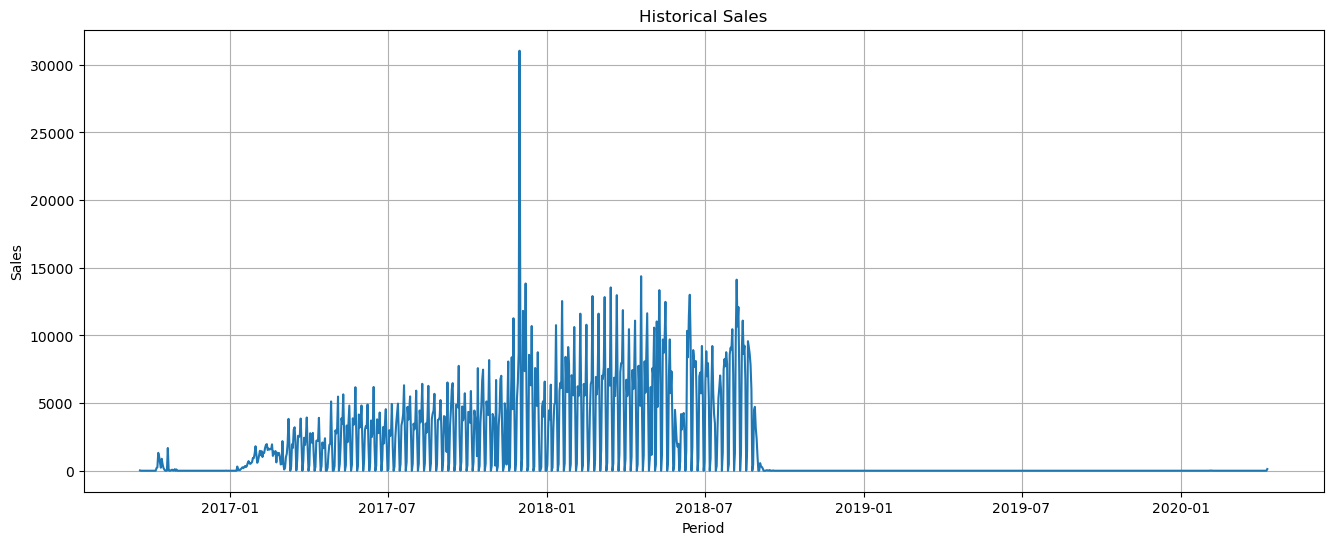

In [23]:
plt.figure(figsize=(16,6))

plt.plot(
    forecast_df["period"],
    forecast_df["sales"]
)

plt.title("Historical Sales")

plt.xlabel("Period")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [24]:
minimum_required = 24

if len(forecast_df) < minimum_required:
    raise RuntimeError(
        "Insufficient observations for meaningful forecasting."
    )

split_index = int(
    len(forecast_df) * 0.80
)

train_df = forecast_df.iloc[:split_index].copy()

test_df = forecast_df.iloc[split_index:].copy()

print(train_df.shape)
print(test_df.shape)

print(train_df["period"].min())
print(train_df["period"].max())

print(test_df["period"].min())
print(test_df["period"].max())

(1039, 3)
(260, 3)
2016-09-19 00:00:00
2019-07-24 00:00:00
2019-07-25 00:00:00
2020-04-09 00:00:00


In [25]:
def smape(actual, predicted):

    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    denominator = np.abs(actual) + np.abs(predicted)

    valid = denominator != 0

    return np.mean(
        2 * np.abs(predicted[valid] - actual[valid]) / denominator[valid]
    ) * 100


def wape(actual, predicted):

    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    denominator = np.sum(np.abs(actual))

    if denominator == 0:
        return np.nan

    return (
        np.sum(np.abs(actual - predicted))
        / denominator
    ) * 100


baseline_prediction = np.repeat(
    train_df["sales"].iloc[-1],
    len(test_df)
)

baseline_mae = mean_absolute_error(
    test_df["sales"],
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test_df["sales"],
        baseline_prediction
    )
)

baseline_smape = smape(
    test_df["sales"],
    baseline_prediction
)

baseline_wape = wape(
    test_df["sales"],
    baseline_prediction
)

baseline_results = pd.DataFrame(
    {
        "Model": ["Naive Forecast"],
        "MAE": [baseline_mae],
        "RMSE": [baseline_rmse],
        "sMAPE": [baseline_smape],
        "WAPE": [baseline_wape]
    }
)

display(baseline_results)

,Model,MAE,RMSE,sMAPE,WAPE
0,Naive Forecast,0.585538,7.728693,200.0,100.0


In [26]:
advanced_available = False

try:

    seasonal_periods = 7 if frequency == "D" else 12

    model = ExponentialSmoothing(
        train_df["sales"],
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    )

    fitted_model = model.fit()

    advanced_prediction = fitted_model.forecast(
        len(test_df)
    )

    advanced_available = True

except Exception as e:

    print(e)

    advanced_available = False

In [27]:
results = baseline_results.copy()

if advanced_available:

    advanced_mae = mean_absolute_error(
        test_df["sales"],
        advanced_prediction
    )

    advanced_rmse = np.sqrt(
        mean_squared_error(
            test_df["sales"],
            advanced_prediction
        )
    )

    advanced_smape = smape(
        test_df["sales"],
        advanced_prediction
    )

    advanced_wape = wape(
        test_df["sales"],
        advanced_prediction
    )

    advanced_results = pd.DataFrame(
        {
            "Model": ["Exponential Smoothing"],
            "MAE": [advanced_mae],
            "RMSE": [advanced_rmse],
            "sMAPE": [advanced_smape],
            "WAPE": [advanced_wape]
        }
    )

    results = pd.concat(
        [
            baseline_results,
            advanced_results
        ],
        ignore_index=True
    )

results = results.sort_values(
    "RMSE"
).reset_index(drop=True)

display(results)

best_model = results.iloc[0]["Model"]

print(best_model)

,Model,MAE,RMSE,sMAPE,WAPE
0,Naive Forecast,0.585538,7.728693,200.0,100.000000
1,Exponential Smoothing,5.523693,10.083780,200.0,943.352804


Naive Forecast


In [28]:
if best_model == "Exponential Smoothing":

    final_model = ExponentialSmoothing(
        forecast_df["sales"],
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    ).fit()

    future_prediction = final_model.forecast(
        FORECAST_HORIZON
    )

else:

    future_prediction = np.repeat(
        forecast_df["sales"].iloc[-1],
        FORECAST_HORIZON
    )

future_dates = pd.date_range(
    start=forecast_df["period"].max(),
    periods=FORECAST_HORIZON + 1,
    freq=frequency
)[1:]

future_forecast = pd.DataFrame(
    {
        "forecast_period": future_dates,
        "predicted_sales": future_prediction,
        "model_name": best_model,
        "forecast_frequency": frequency,
        "forecast_type": "Future"
    }
)

display(future_forecast.head())

,forecast_period,predicted_sales,model_name,forecast_frequency,forecast_type
0,2020-04-10,122.88,Naive Forecast,D,Future
1,2020-04-11,122.88,Naive Forecast,D,Future
2,2020-04-12,122.88,Naive Forecast,D,Future
3,2020-04-13,122.88,Naive Forecast,D,Future
4,2020-04-14,122.88,Naive Forecast,D,Future


In [29]:
forecast_df["model_name"] = best_model
forecast_df["forecast_frequency"] = frequency
forecast_df["forecast_type"] = "Historical"

historical_output = forecast_df.rename(
    columns={
        "period": "forecast_period",
        "sales": "actual_sales"
    }
)

evaluation_path = (
    PREDICTIONS_DIR /
    "sales_forecasting_model_evaluation.csv"
)

historical_path = (
    PREDICTIONS_DIR /
    "sales_forecasting_historical.csv"
)

future_path = (
    PREDICTIONS_DIR /
    "sales_forecasting_future.csv"
)

results.to_csv(
    evaluation_path,
    index=False
)

historical_output.to_csv(
    historical_path,
    index=False
)

future_forecast.to_csv(
    future_path,
    index=False
)

print(evaluation_path)
print(historical_path)
print(future_path)

C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\predictions\sales_forecasting_model_evaluation.csv
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\predictions\sales_forecasting_historical.csv
C:\Users\asus\Documents\ECOMMERCE-AI-PLATFORM\data\predictions\sales_forecasting_future.csv


In [30]:
with engine.begin() as connection:

    connection.execute(
        text("""
        CREATE SCHEMA IF NOT EXISTS forecasting;
        """)
    )

results.to_sql(
    "model_evaluation",
    engine,
    schema="forecasting",
    if_exists="replace",
    index=False
)

historical_output.to_sql(
    "historical_sales_forecast",
    engine,
    schema="forecasting",
    if_exists="replace",
    index=False
)

future_forecast.to_sql(
    "future_sales_forecast",
    engine,
    schema="forecasting",
    if_exists="replace",
    index=False
)

verification = pd.read_sql(
    """
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema='forecasting'
    ORDER BY table_name
    """,
    engine
)

display(verification)

print("Notebook 13 completed successfully.")

,table_name
0,future_sales_forecast
1,historical_sales_forecast
2,model_evaluation


Notebook 13 completed successfully.
